In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt


In [2]:
dataset_path = os.listdir("/content/drive/MyDrive/Dataset/rooms_dataset")

In [3]:
room_type = os.listdir("/content/drive/MyDrive/Dataset/rooms_dataset")
print(room_type)
print("types of room found: ", len(room_type))

['living_room', 'dining_room', 'bed_room']
types of room found:  3


In [4]:
rooms = []

for item in room_type:
    #get all rooms

    all_rooms = os.listdir("/content/drive/MyDrive/Dataset/rooms_dataset" +"/"+ item)

    # adding them to list

    for img in all_rooms:
        rooms.append((item, str("/content/drive/MyDrive/Dataset/rooms_dataset"+"/"+item) +"/"+img))
        print(rooms)

[('living_room', '/content/drive/MyDrive/Dataset/rooms_dataset/living_room/pexels-photo-1571453.jpeg')]
[('living_room', '/content/drive/MyDrive/Dataset/rooms_dataset/living_room/pexels-photo-1571453.jpeg'), ('living_room', '/content/drive/MyDrive/Dataset/rooms_dataset/living_room/photo-1554995207-c18c203602cb (1).jpg')]
[('living_room', '/content/drive/MyDrive/Dataset/rooms_dataset/living_room/pexels-photo-1571453.jpeg'), ('living_room', '/content/drive/MyDrive/Dataset/rooms_dataset/living_room/photo-1554995207-c18c203602cb (1).jpg'), ('living_room', '/content/drive/MyDrive/Dataset/rooms_dataset/living_room/pexels-photo-1571470.jpeg')]
[('living_room', '/content/drive/MyDrive/Dataset/rooms_dataset/living_room/pexels-photo-1571453.jpeg'), ('living_room', '/content/drive/MyDrive/Dataset/rooms_dataset/living_room/photo-1554995207-c18c203602cb (1).jpg'), ('living_room', '/content/drive/MyDrive/Dataset/rooms_dataset/living_room/pexels-photo-1571470.jpeg'), ('living_room', '/content/drive/M

In [5]:
room_df = pd.DataFrame(data = rooms, columns=['room type','image'])
room_df.head()

,room type,image
0,living_room,/content/drive/MyDrive/Dataset/rooms_dataset/l...
1,living_room,/content/drive/MyDrive/Dataset/rooms_dataset/l...
2,living_room,/content/drive/MyDrive/Dataset/rooms_dataset/l...
3,living_room,/content/drive/MyDrive/Dataset/rooms_dataset/l...
4,living_room,/content/drive/MyDrive/Dataset/rooms_dataset/l...


In [6]:
print("Total number of rooms in the dataset: ", len(room_df))

room_count = room_df['room type'].value_counts()
print(room_count)

Total number of rooms in the dataset:  118
room type
bed_room       46
living_room    38
dining_room    34
Name: count, dtype: int64


In [10]:
import cv2 as cv
path = "/content/drive/MyDrive/Dataset/rooms_dataset"

img_size = 224
images = []
labels = []

for i in room_type:
    data_path = path + "/" + str(i)
    filenames = [i for i in os.listdir(data_path)]

   # print(filenames) ## images name only
    for f in filenames:
        img = cv.imread(data_path+"/"+f)

        img = cv.resize(img, (img_size,img_size))
        images.append(img)
        labels.append(i)

labels

['living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'living_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining_room',
 'dining

In [11]:
images = np.array(images)
images.shape

(118, 224, 224, 3)

In [12]:
images = images.astype('float32')/255.0

In [13]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

y = room_df['room type'].values

y_labelEncoder = LabelEncoder()
y = y_labelEncoder.fit_transform(y)

y = y.reshape(-1,1)
onehotencoder = OneHotEncoder(sparse_output=False)
y = onehotencoder.fit_transform(y)
y.shape

(118, 3)

In [14]:
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

images , y = shuffle(images, y , random_state=1)
x_train, x_test, y_train, y_test = train_test_split(images, y, test_size=0.05, random_state=415)

print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)


(112, 224, 224, 3) (6, 224, 224, 3)
(112, 3) (6, 3)


## EfficientNetB0 implementation

In [36]:
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0

NUM_CLASSES = 3
IMG_SIZE = 224
size = (IMG_SIZE, IMG_SIZE)


inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))


# Using model without transfer learning

outputs = EfficientNetB0(include_top=True, weights=None, classes=NUM_CLASSES)(inputs)

In [38]:
model = tensorflow.keras.Model(inputs, outputs)

model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"] )

model.summary()

hist = model.fit(x_train, y_train, epochs=30, verbose=2)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 3)              │     4,053,414 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,053,414 (15.46 MB)

 Trainable params: 4,011,391 (15.30 MB)

 Non-trainable params: 42,023 (164.16 KB)

Epoch 1/30
4/4 - 144s - 36s/step - accuracy: 0.3304 - loss: 5.8249
Epoch 2/30
4/4 - 36s - 9s/step - accuracy: 0.4286 - loss: 3.4359
Epoch 3/30
4/4 - 1s - 136ms/step - accuracy: 0.4018 - loss: 4.0107
Epoch 4/30
4/4 - 1s - 155ms/step - accuracy: 0.5446 - loss: 1.6107
Epoch 5/30
4/4 - 1s - 156ms/step - accuracy: 0.5893 - loss: 1.7700
Epoch 6/30
4/4 - 1s - 130ms/step - accuracy: 0.5357 - loss: 1.5934
Epoch 7/30
4/4 - 1s - 134ms/step - accuracy: 0.5179 - loss: 1.8677
Epoch 8/30
4/4 - 1s - 135ms/step - accuracy: 0.6696 - loss: 1.4217
Epoch 9/30
4/4 - 1s - 147ms/step - accuracy: 0.5714 - loss: 1.2834
Epoch 10/30
4/4 - 0s - 123ms/step - accuracy: 0.7857 - loss: 1.5762
Epoch 11/30
4/4 - 0s - 123ms/step - accuracy: 0.6875 - loss: 1.1151
Epoch 12/30
4/4 - 0s - 125ms/step - accuracy: 0.7589 - loss: 1.2356
Epoch 13/30
4/4 - 0s - 124ms/step - accuracy: 0.8214 - loss: 0.5223
Epoch 14/30
4/4 - 1s - 125ms/step - accuracy: 0.8661 - loss: 0.4232
Epoch 15/30
4/4 - 0s - 122ms/step - accuracy: 0.8036 - loss

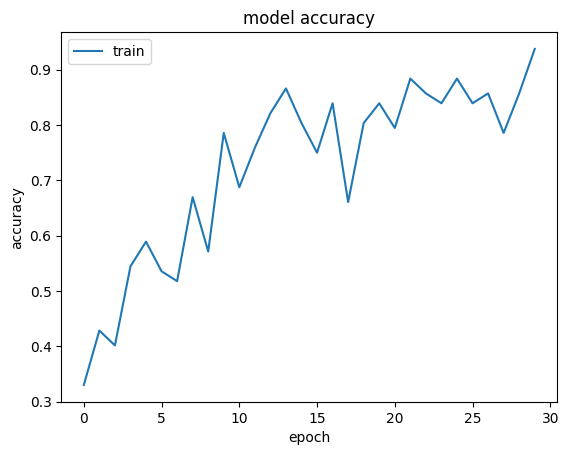

In [39]:
import matplotlib.pyplot as plt


def plot_hist(hist):
    plt.plot(hist.history["accuracy"])
    #plt.plot(hist.history["val_accuracy"])
    plt.title("model accuracy")
    plt.ylabel("accuracy")
    plt.xlabel("epoch")
    plt.legend(["train", "validation"], loc="upper left")
    plt.show()


plot_hist(hist)

In [41]:
preds = model.evaluate(x_test, y_test)
print ("Loss = " + str(preds[0]))
print ("Test Accuracy = " + str(preds[1]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 17s 17s/step - accuracy: 0.1667 - loss: 4.7039
Loss = 4.703936576843262
Test Accuracy = 0.1666666716337204


## Testing on unseen data

Input image shape: (1, 224, 224, 3)


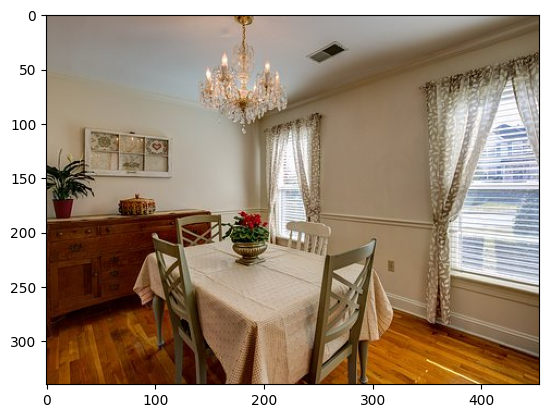

In [43]:
from matplotlib.pyplot import imread
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.applications.imagenet_utils import preprocess_input
import cv2


img_path = '/content/drive/MyDrive/Dataset/rooms_dataset/dining_room/interior-3674959__340.jpg'

#img = image.load_img(img_path, target_size=(224, 224))
#x = img.img_to_array(img)

img = cv2.imread(img_path)
img = cv2.resize(img, (224, 224))

x = np.expand_dims(img, axis=0)
x = preprocess_input(x)

print('Input image shape:', x.shape)

my_image = imread(img_path)
imshow(my_image)

In [44]:
preds=model.predict(x)
preds

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


array([[9.8602641e-01, 3.8148731e-04, 1.3592202e-02]], dtype=float32)

# **Transfer Learning**

In [45]:
import cv2
import numpy as np
from matplotlib.pyplot import imread
from matplotlib.pyplot import imshow
from tensorflow.keras.preprocessing import image
from tensorflow.keras.applications.imagenet_utils import decode_predictions
from tensorflow.keras.applications.imagenet_utils import preprocess_input
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0
import numpy as np
import tensorflow as tf

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os


NUM_CLASSES = 3
IMG_SIZE = 224

In [46]:
def build_model(num_classes):
    inputs = layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    #x = img_augmentation(inputs)
    x = inputs
    model = EfficientNetB0(include_top=False, input_tensor=x, weights="imagenet")

    # Freeze the pretrained weights
    model.trainable = False

    # Rebuild top
    x = layers.GlobalAveragePooling2D(name="avg_pool")(model.output)
    x = layers.BatchNormalization()(x)

    top_dropout_rate = 0.2
    x = layers.Dropout(top_dropout_rate, name="top_dropout")(x)
    outputs = layers.Dense(NUM_CLASSES, activation="softmax", name="pred")(x)

    # Compile
    model = tf.keras.Model(inputs, outputs, name="EfficientNet")
    optimizer = tf.keras.optimizers.Adam(learning_rate=1e-2)
    model.compile(
        optimizer=optimizer, loss="categorical_crossentropy", metrics=["accuracy"]
    )
    return model

In [47]:
model = build_model(num_classes=NUM_CLASSES)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Epoch 1/30
4/4 - 34s - 9s/step - accuracy: 0.3482 - loss: 1.5677
Epoch 2/30
4/4 - 0s - 55ms/step - accuracy: 0.3750 - loss: 2.0417
Epoch 3/30
4/4 - 0s - 49ms/step - accuracy: 0.3214 - loss: 1.6689
Epoch 4/30
4/4 - 0s - 44ms/step - accuracy: 0.3393 - loss: 1.6519
Epoch 5/30
4/4 - 0s - 45ms/step - accuracy: 0.3304 - loss: 1.5618
Epoch 6/30
4/4 - 0s - 44ms/step - accuracy: 0.3661 - loss: 1.5868
Epoch 7/30
4/4 - 0s - 43ms/step - accuracy: 0.3304 - loss: 1.4019
Epoch 8/30
4/4 - 0s - 44ms/step - accuracy: 0.2679 - loss: 2.0264
Epoch 9/30
4/4 - 0s - 45ms/step - accuracy: 0.4107 - loss: 1.3645
Epoch 10/30
4/4 - 0s - 44ms/step - accuracy: 0.3839 - loss: 1.6504
Epoch 11/30
4/4 - 0s - 44ms/step - accuracy: 0.3661 - loss: 1.6139
Epoch 12/30
4/4 - 0s - 44ms/step - accuracy: 0.3839 - loss: 1.3090
Epoch 13/30
4/4 - 0s - 51ms/step - accuracy: 0.2768 - loss: 1.4668
Epoch 14/30
4/4 - 0s - 54ms/step - accuracy: 0.3661 - loss: 1.8586
Epoch 15/30
4/4 - 0s - 53ms/step - accuracy: 0.3214 - loss: 1.3669
Epoch

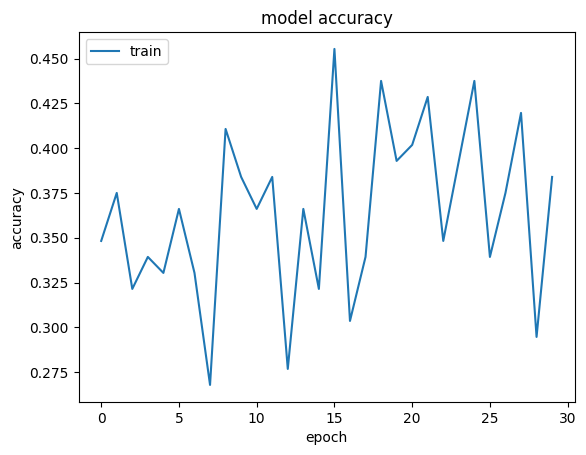

In [52]:
epochs = 30
hist = model.fit(x_train, y_train, epochs=epochs, verbose=2)
plot_hist(hist)

In [55]:
preds = model.evaluate(x_train, y_train)
print ("Loss = " + str(preds[0]))
print ("Test Accuracy = " + str(preds[1]))

4/4 ━━━━━━━━━━━━━━━━━━━━ 14s 1s/step - accuracy: 0.3125 - loss: 1.0893
Loss = 1.0892772674560547
Test Accuracy = 0.3125
